# 04. Simulación de Ejecución y Costes Transaccionales

En este notebook implementamos el motor de ejecución profesional. Hasta ahora hemos calculado los pesos teóricos, pero en el mundo real:
1. No operamos al precio de cierre de la señal, sino a precios posteriores.
2. Existen comisiones mínimas y porcentuales que pueden destruir la rentabilidad de una estrategia si rotamos demasiado.

### Reglas de Ejecución Estrictas:
- **Venta**: Activos que salen de cartera se cierran al precio **OPEN** del día de rebalanceo.
- **Compra**: Nuevos activos se adquieren al precio **CLOSE** del mismo día.
- **Comisiones**: 0.23% por operación, con un **mínimo de 23$** por orden.

### 1. Carga de Datos y Pesos
Necesitamos los pesos generados en el NB 03 y los precios Open/Close que preparamos en el NB 02.

In [1]:
import pandas as pd
import numpy as np
# Cargar pesos mensuales
weights_df = pd.read_csv('Datos/momentum_weights.csv', index_col=0, parse_dates=True)

# Cargar precios de ejecución (Open/Close diarios)
exec_prices = pd.read_csv('Datos/momentum_execution_prices.csv', index_col=0, parse_dates=True)

# Filtrar por el periodo de la práctica (Desde 2010)
start_date = '2010-01-01'
weights_df = weights_df[weights_df.index >= start_date]

print(f"✅ Datos cargados. Periodo de simulación: {weights_df.index.min().date()} a {weights_df.index.max().date()}")

✅ Datos cargados. Periodo de simulación: 2015-01-30 a 2026-01-30


In [2]:
weights_df.shape, exec_prices.shape

((133, 1278), (9087, 2556))

### 2. Motor de Backtesting con Costes
Implementamos una clase para gestionar la cartera, las órdenes y las comisiones.

In [3]:
date = '2010-10-29'
t=  'VSTNQ-201010'
exec_prices.loc[date, f'{t}_OPEN'] , exec_prices.loc[date, f'{t}_CLOSE'], exec_prices.loc[exec_prices.index<date, f'{t}_CLOSE'].dropna()

(np.float64(nan),
 np.float64(nan),
 date
 2000-06-29    13.7500
 2000-06-30    12.1250
 2000-07-03    12.8125
 2000-07-05    12.0625
 2000-07-06    12.8125
                ...   
 2005-12-23     6.9200
 2005-12-27     6.8600
 2005-12-28     6.5100
 2005-12-29     6.3900
 2005-12-30     6.2600
 Name: VSTNQ-201010_CLOSE, Length: 1384, dtype: float64)

In [4]:
class BacktestEngine:
    def __init__(self, initial_capital=250000, commission_pct=0.0023, min_commission=23):
        self.cash = initial_capital
        self.holdings = {} 
        self.commission_pct = commission_pct
        self.min_commission = min_commission
        self.history = []
        self.total_commissions = 0
        
    def calculate_commission(self, value):
        if value == 0: raise Exception ("Operación Nula")
        comm = abs(value) * self.commission_pct
        return max(self.min_commission, comm)

    def run(self, weights_df, prices_df):
        date_prev = None
        for date, target_weights in weights_df.iterrows():
            active_targets = target_weights[target_weights > 0]

            # --- 1. FASE Salidas totales ---
            tickers_exit = [t for t in self.holdings.keys() if t not in active_targets.index]
            for ticker in tickers_exit:
                col_open = f"{ticker}_OPEN"
                col_close = f"{ticker}_CLOSE"
                sell_price = prices_df.loc[date, col_open]
                # Si no hay OPEN (delisting), usamos el precio de cierre del último día de cotización
                if pd.isna(sell_price):
                    sell_price = prices_df.loc[np.logical_and(prices_df.index >= date_prev, prices_df.index < date), col_close].dropna().iloc[-1]

                qty = self.holdings.pop(ticker)
                value = qty * sell_price
                comm = self.calculate_commission(value)
                self.cash += (value - comm)
                self.total_commissions += comm

            # --- 2. CÁLCULO DE NAV ACTUAL ---
            # Usamos los precios de open en el que ejecutaremos todas las ventas para que el valor de la cartera sea real
            current_portfolio_value = self.cash
            for ticker, qty in self.holdings.items():
                col_open = f"{ticker}_OPEN"
                col_close = f"{ticker}_CLOSE"
                p = prices_df.loc[prices_df.index<date, col_close].iloc[-1]
                current_portfolio_value += qty * p

            # --- 3. FASE Ventas por rebalanceo (Excedentes del 5%)
            for ticker, weight in active_targets.items():
                col_open = f"{ticker}_OPEN"
                col_close = f"{ticker}_CLOSE"
                if ticker in self.holdings:
                    price = prices_df.loc[prices_df.index<date, col_close].iloc[-1]
                    
                    target_qty = int((current_portfolio_value * weight) // price)
                    current_qty = self.holdings[ticker]
                    
                    if current_qty > target_qty:
                        diff = current_qty - target_qty
                        sell_price = prices_df.loc[date, col_open]
                        # Si no hay OPEN (delisting), usamos el precio de cierre del último día de cotización
                        if pd.isna(sell_price):
                            sell_price = prices_df.loc[np.logical_and(prices_df.index >= date_prev, prices_df.index < date), col_close].dropna().iloc[-1]
                        val = diff * sell_price
                        comm = self.calculate_commission(val)
                        self.holdings[ticker] = target_qty
                        self.cash += (val - comm)
                        self.total_commissions += comm

            # --- 4. FASE DE COMPRAS ---
            for ticker, weight in active_targets.items():
                col_open = f"{ticker}_OPEN"
                col_close = f"{ticker}_CLOSE"
                price = prices_df.loc[prices_df.index<date, col_close].iloc[-1]
                
                target_qty = int((current_portfolio_value * weight) // price)
                current_qty = self.holdings.get(ticker, 0)
                
                if target_qty > current_qty:
                    diff = target_qty - current_qty
                    buy_price = prices_df.loc[date, col_close]
                    trade_val = diff * buy_price
                    comm = self.calculate_commission(trade_val)
                    
                    if (trade_val + comm) <= self.cash:
                        self.holdings[ticker] = current_qty + diff
                        self.cash -= (trade_val + comm)
                        self.total_commissions += comm
                    else:
                        # Compra máxima posible con el cash restante. Restamos la comm máxima para asegurar
                        max_q = int((self.cash - comm) // buy_price)
                        if max_q > 0:
                            val = max_q * buy_price
                            c = self.calculate_commission(val)
                            self.holdings[ticker] = current_qty + max_q
                            self.cash -= (val + c)
                            self.total_commissions += c

            # --- 5. SNAPSHOT FINAL ---
            final_value = self.cash
            for t, q in self.holdings.items():
                col_close = f"{t}_CLOSE"
                p = prices_df.loc[date, col_close]
                v = q * p
                final_value += v

            pos_weights = {}
            for t, q in self.holdings.items():
                col_close = f"{t}_CLOSE"
                p = prices_df.loc[date, col_close]
                v = q * p
                pos_weights[t] = (v / final_value)

            self.history.append({
                'Date': date,
                'TotalValue': final_value,
                'Cash': self.cash,
                'TotalCommissions': self.total_commissions,
                'Holdings': self.holdings.copy(),
                'Weights': pos_weights
            })
            date_prev = date
            
        return pd.DataFrame(self.history).set_index('Date')

initial_capital=250000
engine = BacktestEngine(initial_capital=initial_capital)
results = engine.run(weights_df, exec_prices)
results['CumulativeReturn'] = results['TotalValue'] / initial_capital
results.to_csv('Datos/backtest_results_with_costs.csv')

print("✅ Simulación completada.")
print(f"💰 Comisiones totales pagadas: {engine.total_commissions:,.2f} $")
print("\nÚltimos resultados:")
print(results.loc[:, ['TotalValue','Cash','CumulativeReturn']].tail())

✅ Simulación completada.
💰 Comisiones totales pagadas: 106,307.22 $

Últimos resultados:
               TotalValue         Cash  CumulativeReturn
Date                                                    
2025-09-30  399626.114903  2495.584903          1.598504
2025-10-31  407249.554408    13.304408          1.628998
2025-11-28  400982.224702   108.014702          1.603929
2025-12-31  412982.754201  3341.724201          1.651931
2026-01-30  481338.710737  3739.520737          1.925355


In [5]:
results.iloc[-1]

TotalValue                                              481338.710737
Cash                                                      3739.520737
TotalCommissions                                        106307.222987
Holdings            {'TPR': 195, 'APH': 166, 'STX': 55, 'WDC': 89,...
Weights             {'TPR': 0.051413795416785764, 'APH': 0.0496890...
CumulativeReturn                                             1.925355
Name: 2026-01-30 00:00:00, dtype: object

### Código de Auditoría y Verificación
Este bloque de código analiza los resultados obtenidos para confirmar que se cumplen tus restricciones de negocio.

In [6]:
def verify_backtest(results_df):
    print("--- 🛡️ INICIANDO AUDITORÍA DE BACKTEST ---")
    
    # 1. Verificar Cash Negativo
    min_cash = results_df['Cash'].min()
    cash_ok = min_cash >= 0
    print(f"【CASH】 Mínimo nivel de caja: {min_cash:,.2f}$ -> {'✅ OK' if cash_ok else '❌ ERROR: CAJA NEGATIVA'}")

    # 2. Verificar Cantidades Enteras
    fractional_error = False
    for entry in results_df['Holdings']:
        if any(not float(q).is_integer() for q in entry.values()):
            fractional_error = True
            break
    print(f"【ACCIONES】 Solo cantidades enteras: {'✅ OK' if not fractional_error else '❌ ERROR: HAY MEDIAS ACCIONES'}")

    # 3. Verificar Pesos (aprox 5%)
    # Analizamos todos los pesos de todos los activos en todas las fechas
    all_weights = []
    for w_dict in results_df['Weights']:
        all_weights.extend(w_dict.values())
    
    avg_w = np.mean(all_weights)
    max_w = np.max(all_weights)
    min_w = np.min(all_weights)
    
    print(f"【PESOS】 Peso objetivo: 5.00%")
    print(f"       - Media real: {avg_w*100:.2f}%")
    print(f"       - Máximo: {max_w*100:.2f}%")
    print(f"       - Mínimo: {min_w*100:.2f}%")
    
    # Tolerancia: permitimos desviación por redondeo de acciones (ej. 4.5% a 5.5%)
    if 0.04 <= avg_w <= 0.06:
        print("【RESULTADO】 Distribución de pesos: ✅ OK (Dentro de tolerancia de redondeo)")
    else:
        print("【RESULTADO】 Distribución de pesos: ⚠️ REVISAR (Mucha desviación)")

# Ejecución
# engine = BacktestEngine()
# results = engine.run(weights_df, prices_df)
verify_backtest(results)

--- 🛡️ INICIANDO AUDITORÍA DE BACKTEST ---
【CASH】 Mínimo nivel de caja: 4.68$ -> ✅ OK
【ACCIONES】 Solo cantidades enteras: ✅ OK
【PESOS】 Peso objetivo: 5.00%
       - Media real: 4.97%
       - Máximo: 5.63%
       - Mínimo: 1.35%
【RESULTADO】 Distribución de pesos: ✅ OK (Dentro de tolerancia de redondeo)


### 3. Visualización del Impacto de los Costes

In [7]:
results.tail()

,TotalValue,Cash,TotalCommissions,Holdings,Weights,CumulativeReturn
Date,,,,,,
2025-09-30,399626.114903,2495.584903,103069.043015,"{'HWM': 103, 'AXON': 27, 'TPR': 178, 'GEV': 33...","{'HWM': 0.05057649949860294, 'AXON': 0.0484860...",1.598504
2025-10-31,407249.554408,13.304408,103934.464200,"{'HWM': 100, 'TPR': 182, 'GEV': 35, 'NRG': 117...","{'HWM': 0.050570957726289806, 'TPR': 0.0490786...",1.628998
2025-11-28,400982.224702,108.014702,104741.905412,"{'HWM': 97, 'TPR': 179, 'GEV': 33, 'NRG': 118,...","{'HWM': 0.04949154545383986, 'TPR': 0.04878301...",1.603929
2025-12-31,412982.754201,3341.724201,105623.654523,"{'TPR': 161, 'APH': 153, 'STX': 74, 'AVGO': 59...","{'TPR': 0.04981072403328305, 'APH': 0.05006606...",1.651931
2026-01-30,481338.710737,3739.520737,106307.222987,"{'TPR': 195, 'APH': 166, 'STX': 55, 'WDC': 89,...","{'TPR': 0.051413795416785764, 'APH': 0.0496890...",1.925355


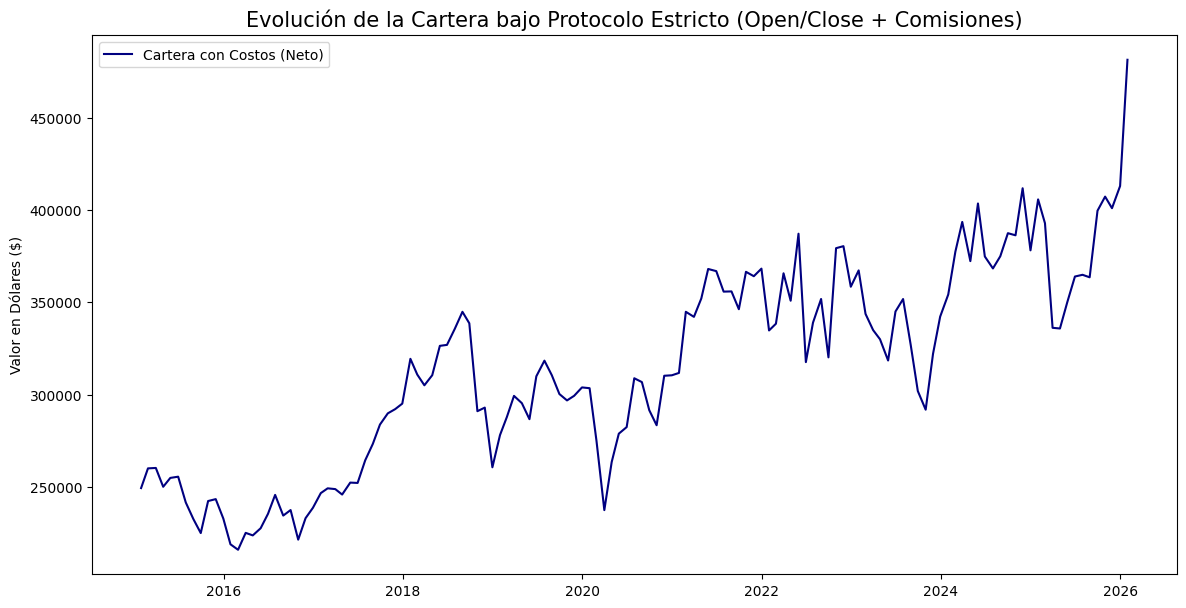

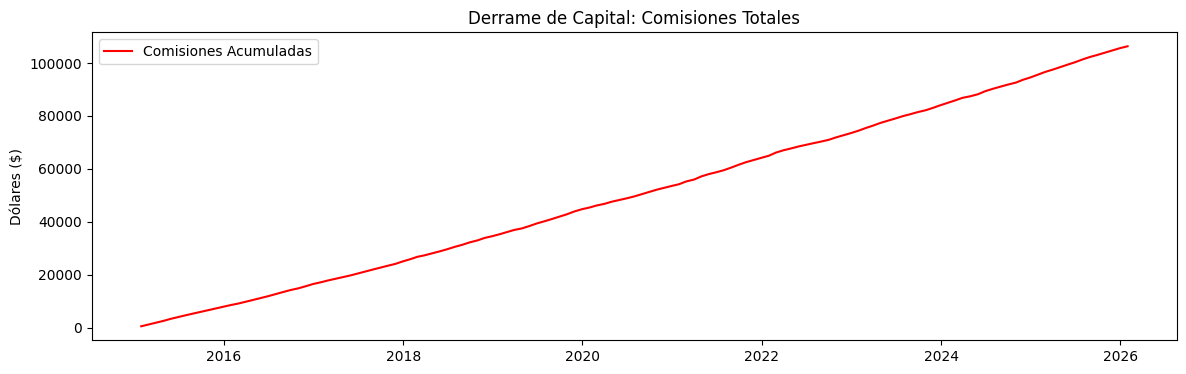

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
plt.plot(results['TotalValue'], label='Cartera con Costos (Neto)', color='navy')
plt.title('Evolución de la Cartera bajo Protocolo Estricto (Open/Close + Comisiones)', fontsize=15)
plt.ylabel('Valor en Dólares ($)')
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(results['TotalCommissions'], color='red', label='Comisiones Acumuladas')
plt.title('Derrame de Capital: Comisiones Totales')
plt.ylabel('Dólares ($)')
plt.legend()
plt.show()

### 4. Simulación Virtual (Ideal sin Costes)
Para medir el impacto real de nuestras ineficiencias, realizamos una simulación 'hermética' donde compramos y vendemos al precio de cierre del día de la señal y sin pagar comisiones.

In [9]:
# Ejecutar Backtest Virtual (Sin comisiones, todo a CLOSE)
engine_virtual = BacktestEngine(commission_pct=0, min_commission=0)

# Pequeño ajuste al motor para modo virtual si fuera necesario, 
# pero usaremos la misma lógica para que sea comparable
results_virtual = engine_virtual.run(weights_df, exec_prices)
results_virtual['CumulativeReturn'] = results_virtual['TotalValue'] / 250000

print("✅ Simulación Virtual Completada.")

✅ Simulación Virtual Completada.


In [10]:
results_virtual['CumulativeReturn'] 

Date
2015-01-30    1.000000
2015-02-27    1.045244
2015-03-31    1.049078
2015-04-30    1.010723
2015-05-29    1.033169
                ...   
2025-09-30    2.229508
2025-10-31    2.276990
2025-11-28    2.246596
2025-12-31    2.318788
2026-01-30    2.707034
Name: CumulativeReturn, Length: 133, dtype: float64

### 5. Comparativa Final: Real vs Virtual
Este gráfico revela el 'coste de oportunidad' y el impacto de los gastos mínimos.

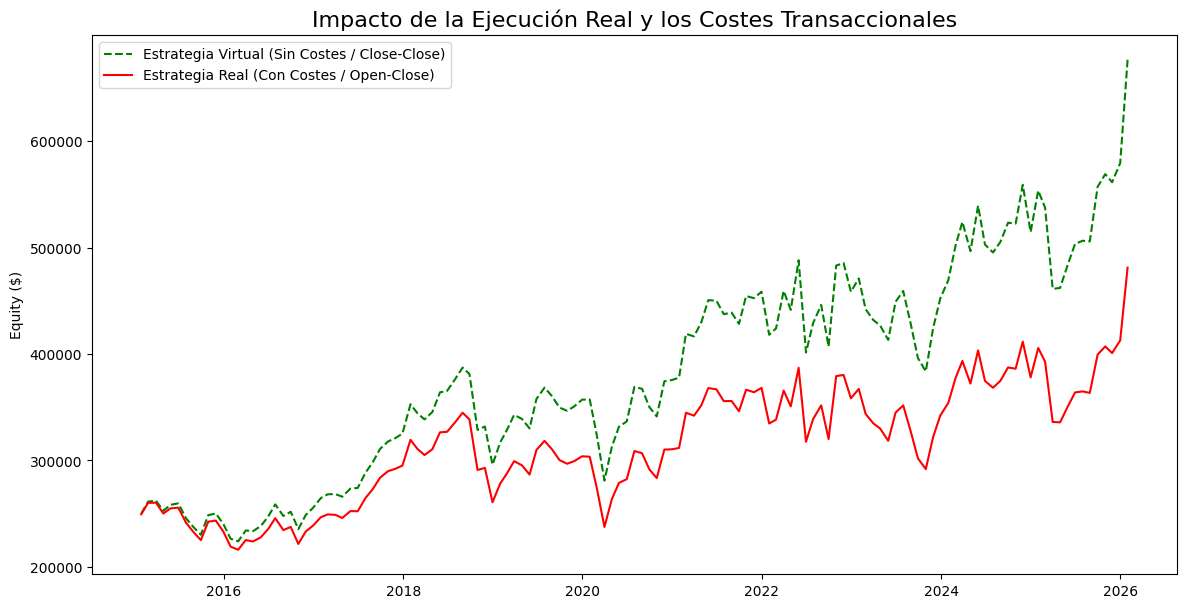

📉 El impacto total de los costes y la ejecución ha sido de un -28.88% sobre el capital final ideal.


In [11]:
plt.figure(figsize=(14, 7))
plt.plot(results_virtual['TotalValue'], label='Estrategia Virtual (Sin Costes / Close-Close)', color='green', linestyle='--')
plt.plot(results['TotalValue'], label='Estrategia Real (Con Costes / Open-Close)', color='red')
plt.title('Impacto de la Ejecución Real y los Costes Transaccionales', fontsize=16)
plt.ylabel('Equity ($)')
plt.legend()
plt.show()

# Guardar ambos resultados para el análisis de robustez
results.to_csv('Datos/backtest_results_real.csv')
results_virtual.to_csv('Datos/backtest_results_virtual.csv')

impacto_pct = (results['TotalValue'].iloc[-1] / results_virtual['TotalValue'].iloc[-1] - 1) * 100
print(f"📉 El impacto total de los costes y la ejecución ha sido de un {impacto_pct:.2f}% sobre el capital final ideal.")

In [12]:
results.columns

Index(['TotalValue', 'Cash', 'TotalCommissions', 'Holdings', 'Weights',
       'CumulativeReturn'],
      dtype='str')

In [13]:
# comisión media por rebalanceo

results["Commission"] = results["TotalCommissions"].diff()
results.loc[results.index[0],"Commission"] = results.loc[results.index[0],"TotalCommissions"]
print((results["Commission"]/results["TotalValue"]).mean()*100, "%")

0.25832879960876654 %
